=== Korelasi Pearson fitur numerik dengan class (encoded) ===

age: -0.220
-> Hubungan linear lemah atau tidak ada

alk_phosphate: -0.148
-> Hubungan linear lemah atau tidak ada

sgot: -0.088
-> Hubungan linear lemah atau tidak ada

albumin: 0.466
-> Hubungan linear sedang

protime: 0.307
-> Hubungan linear sedang

💡 Rekomendasi: Gunakan **SVM dengan kernel NON-LINEAR (RBF)** karena hubungan linear kurang kuat.


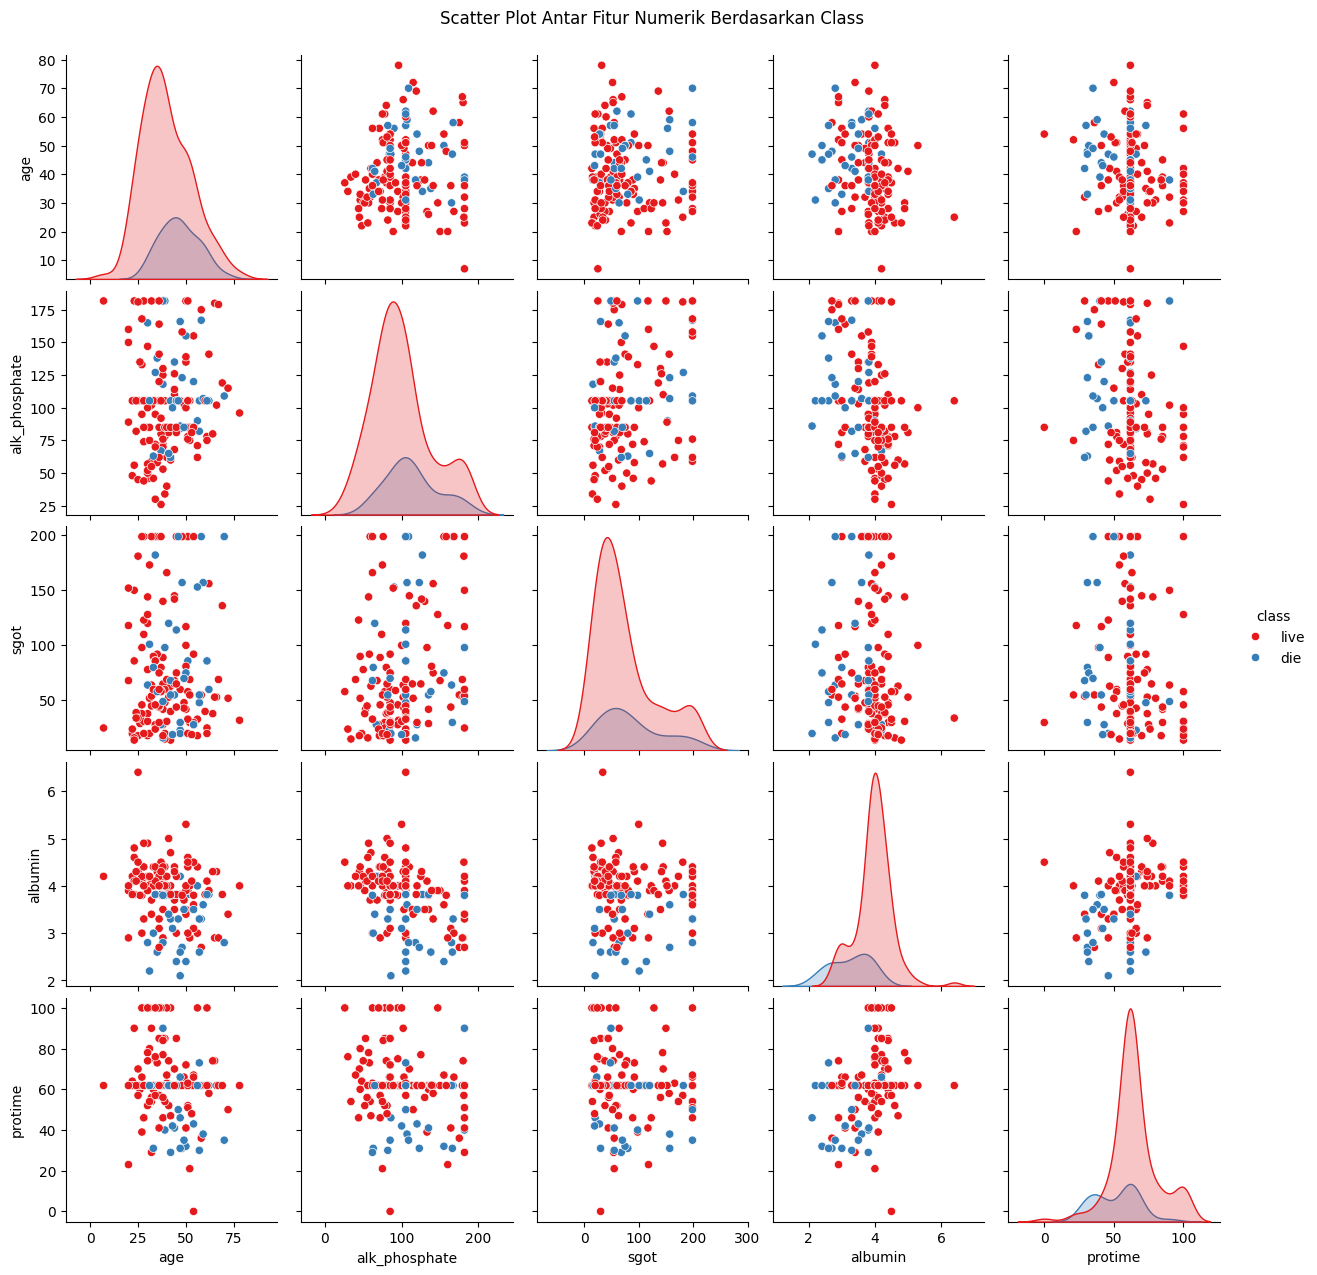

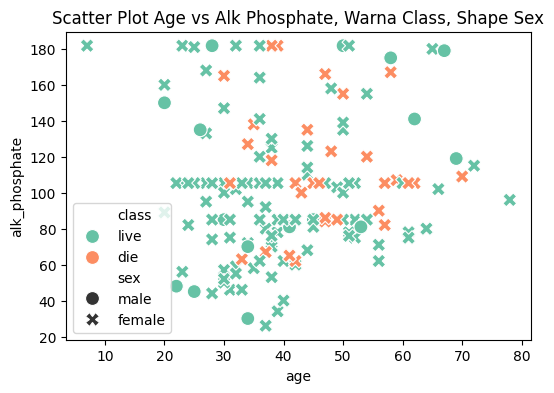

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

numerical_features = ['age', 'alk_phosphate', 'sgot', 'albumin', 'protime']

# Encode target class (die = 0, live = 1)
data['class_encoded'] = data['class'].astype('category').cat.codes

# 🔍 Korelasi Pearson antara fitur numerik dan class_encoded
print("=== Korelasi Pearson fitur numerik dengan class (encoded) ===\n")
linear_corr_count = 0
for feature in numerical_features:
    corr = data[feature].corr(data['class_encoded'])
    print(f"{feature}: {corr:.3f}")
    if abs(corr) > 0.7:
        print("-> Hubungan linear kuat\n")
        linear_corr_count += 1
    elif abs(corr) > 0.3:
        print("-> Hubungan linear sedang\n")
        linear_corr_count += 1
    else:
        print("-> Hubungan linear lemah atau tidak ada\n")

# 🎯 Rekomendasi Kernel
if linear_corr_count >= len(numerical_features) / 2:
    print("💡 Rekomendasi: Gunakan **SVM dengan kernel LINEAR** (hubungan linear cukup kuat).")
else:
    print("💡 Rekomendasi: Gunakan **SVM dengan kernel NON-LINEAR (RBF)** karena hubungan linear kurang kuat.")

# 📊 Visualisasi Pairplot
sns.pairplot(data, vars=numerical_features, hue='class', diag_kind='kde', palette='Set1')
plt.suptitle('Scatter Plot Antar Fitur Numerik Berdasarkan Class', y=1.02)
plt.show()

# 📊 Visualisasi Scatter Plot (kombinasi kategorikal vs numerik)
plt.figure(figsize=(6,4))
sns.scatterplot(data=data, x='age', y='alk_phosphate', hue='class', style='sex', palette='Set2', s=100)
plt.title('Scatter Plot Age vs Alk Phosphate, Warna Class, Shape Sex')
plt.show()

# Bersihkan kolom tambahan
data.drop(columns=['class_encoded'], inplace=True)

Hasil scatter plot antar fitur numerik berdasarkan kelas (live dan die) menunjukkan bahwa hubungan antara sebagian besar pasangan fitur bersifat non-linear. Hal ini terlihat dari sebaran titik-titik pada plot yang tidak membentuk pola garis lurus atau tren linear yang jelas. Misalnya, pada pasangan fitur seperti age vs sgot, alk_phosphate vs albumin, dan sgot vs protime, titik-titik data tersebar secara acak dan tidak menunjukkan hubungan linier yang konsisten antara fitur tersebut. Selain itu, terdapat tumpang tindih (overlap) yang signifikan antara kelas “live” dan “die” di hampir semua kombinasi fitur, yang memperkuat indikasi bahwa model linear sederhana mungkin tidak cukup efektif untuk memisahkan kedua kelas ini dengan baik. Oleh karena itu, pendekatan non-linear seperti Support Vector Machine dengan kernel non-linear bisa lebih sesuai untuk menangani pola data seperti ini.

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

print(f"\n🔨 MEMBANGUN BASELINE SVM DENGAN KERNEL RBF")
print("Parameter default: kernel='rbf', C=1.0, gamma='scale'")

# Inisialisasi model
svm_rbf = SVC(
    kernel='rbf',     # Gunakan kernel Gaussian RBF
    C=1.0,            # Parameter regulasi (default)
    gamma='scale',    # Otomatis menyesuaikan gamma berdasarkan fitur (default)
    random_state=42
)

# Latih model
svm_rbf.fit(X_train, y_train)

# Evaluasi akurasi pada data test
y_pred = svm_rbf.predict(X_test)
accuracy_baseline = accuracy_score(y_test, y_pred)

# Cross-validation (CV)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_baseline = cross_val_score(svm_rbf, X_train, y_train, cv=cv, scoring='accuracy')

print(f"\n📊 HASIL EVALUASI SVM RBF:")
print(f"  Test Accuracy   : {accuracy_baseline:.4f} ({accuracy_baseline*100:.2f}%)")
print(f"  CV Accuracy     : {cv_scores_baseline.mean():.4f} (±{cv_scores_baseline.std()*2:.4f})")


🔨 MEMBANGUN BASELINE SVM DENGAN KERNEL RBF
Parameter default: kernel='rbf', C=1.0, gamma='scale'

📊 HASIL EVALUASI SVM RBF:
  Test Accuracy   : 0.7949 (79.49%)
  CV Accuracy     : 0.7931 (±0.0337)


In [ ]:
# =============================================================================
# STEP 3A: EKSPLORASI MODEL - SKEMA 1 (SVM RBF + SCALING + GRIDSEARCH)
# =============================================================================

print(f"\n🔬 STEP 3A: EKSPLORASI MODEL - SKEMA 1 (DENGAN SCALING)")
print("="*50)

print(f"\n🧠 SKEMA 1 : SVM (RBF) + SCALING + GRIDSEARCH")

# Scaling input
scaler_1 = StandardScaler()
X_train_scaled_1 = scaler_1.fit_transform(X_train)
X_test_scaled_1 = scaler_1.transform(X_test)

# Model SVM dengan kernel RBF
svm_1 = SVC(kernel='rbf')

# Parameter grid untuk tuning
param_grid_1 = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.01, 0.1, 1]
}

# GridSearch dengan cross-validation
grid_search_1 = GridSearchCV(
    svm_1,
    param_grid=param_grid_1,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1
)

# Training dengan data yang sudah diskalakan
grid_search_1.fit(X_train_scaled_1, y_train)

# Evaluasi hasil terbaik
best_svm_1 = grid_search_1.best_estimator_
y_pred_1 = best_svm_1.predict(X_test_scaled_1)
accuracy_1 = accuracy_score(y_test, y_pred_1)

print(f"\n📊 HASIL SKEMA 1:")
print(f"  Best Parameters: {grid_search_1.best_params_}")
print(f"  Best CV Score: {grid_search_1.best_score_:.4f}")
print(f"  Test Accuracy: {accuracy_1:.4f} ({accuracy_1*100:.2f}%)")


🔬 STEP 3A: EKSPLORASI MODEL - SKEMA 1 (DENGAN SCALING)

🧠 SKEMA 1 : SVM (RBF) + SCALING + GRIDSEARCH

📊 HASIL SKEMA 1:
  Best Parameters: {'C': 10, 'gamma': 0.1}
  Best CV Score: 0.8710
  Test Accuracy: 0.7949 (79.49%)


In [ ]:
# =============================================================================
# STEP 3B: EKSPLORASI MODEL - SKEMA 2 (SVM + FEATURE SELECTION)
# =============================================================================

print(f"\n🔬 STEP 3B: EKSPLORASI MODEL - SKEMA 2 (DENGAN FEATURE SELECTION)")
print("="*50)

# Skema 2: RobustScaler + Feature Selection + GridSearch untuk SVM
print("🔧 SKEMA 2: RobustScaler + Feature Selection + GridSearch (SVM)")

from sklearn.svm import SVC
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score

# Scaling
scaler_2 = RobustScaler()
X_train_scaled_2 = scaler_2.fit_transform(X_train)
X_test_scaled_2 = scaler_2.transform(X_test)

# Feature Selection
feature_selector_2 = SelectKBest(score_func=f_classif, k=min(10, X_train.shape[1]))
X_train_selected = feature_selector_2.fit_transform(X_train_scaled_2, y_train)
X_test_selected = feature_selector_2.transform(X_test_scaled_2)

# Menampilkan fitur yang terpilih
selected_mask = feature_selector_2.get_support()
selected_features = [feature for feature, selected in zip(X.columns, selected_mask) if selected]

print(f"📊 Features selected: {X_train_selected.shape[1]} dari {X_train.shape[1]}")
print(f"📌 Selected Features: {selected_features}")

# GridSearch parameter untuk SVM (RBF Kernel)
param_grid_svm_2 = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['rbf']
}

# GridSearchCV
grid_search_2 = GridSearchCV(
    SVC(),
    param_grid=param_grid_svm_2,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1
)

grid_search_2.fit(X_train_selected, y_train)

# Evaluasi
best_svm_2 = grid_search_2.best_estimator_
y_pred_svm_2 = best_svm_2.predict(X_test_selected)
accuracy_2 = accuracy_score(y_test, y_pred_svm_2)

print(f"\n📊 HASIL SKEMA 2 (SVM RBF):")
print(f"  Best Parameters: {grid_search_2.best_params_}")
print(f"  Best CV Score: {grid_search_2.best_score_:.4f}")
print(f"  Test Accuracy: {accuracy_2:.4f} ({accuracy_2*100:.2f}%)")


🔬 STEP 3B: EKSPLORASI MODEL - SKEMA 2 (DENGAN FEATURE SELECTION)
🔧 SKEMA 2: RobustScaler + Feature Selection + GridSearch (SVM)
📊 Features selected: 10 dari 19
📌 Selected Features: ['age', 'fatigue', 'malaise', 'spiders', 'ascites', 'varices', 'bilirubin', 'albumin', 'protime', 'histology']

📊 HASIL SKEMA 2 (SVM RBF):
  Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
  Best CV Score: 0.8619
  Test Accuracy: 0.8718 (87.18%)


In [ ]:
# =============================================================================
# STEP 3C: EKSPLORASI MODEL - SKEMA 3 (SVM RBF + ADVANCED TUNING)
# =============================================================================

print(f"\n🔬 STEP 3C: EKSPLORASI MODEL - SKEMA 3 (ADVANCED TUNING)")
print("="*50)
print(f"\n🧠 SKEMA 3: MinMaxScaler + Mutual Info Feature Selection + SVM RBF Tuning")

from sklearn.svm import SVC

# 1. Scaling
scaler_3_svm = MinMaxScaler()
X_train_scaled_3_svm = scaler_3_svm.fit_transform(X_train)
X_test_scaled_3_svm = scaler_3_svm.transform(X_test)

# Cek NaN
if np.isnan(X_train_scaled_3_svm).any() or np.isnan(X_test_scaled_3_svm).any():
    print("⚠️ NaN detected! Replacing with 0")
    X_train_scaled_3_svm = np.nan_to_num(X_train_scaled_3_svm)
    X_test_scaled_3_svm = np.nan_to_num(X_test_scaled_3_svm)

# 2. Feature selection (mutual information) - eksplorasi k
max_features_svm = X_train.shape[1]
k_values_svm = list(range(4, max_features_svm + 1, 2))
if max_features_svm not in k_values_svm:
    k_values_svm.append(max_features_svm)

best_k_svm = None
best_score_svm = 0
k_scores_svm = {}

for k in k_values_svm:
    if k == max_features_svm:
        X_train_temp = X_train_scaled_3_svm
    else:
        selector = SelectKBest(score_func=mutual_info_classif, k=k)
        X_train_temp = selector.fit_transform(X_train_scaled_3_svm, y_train)

    svm_temp = SVC(kernel='rbf', C=1.0, gamma='scale')
    scores = cross_val_score(svm_temp, X_train_temp, y_train, cv=3, scoring='accuracy')
    avg = scores.mean()
    k_scores_svm[k] = avg

    if avg > best_score_svm:
        best_score_svm = avg
        best_k_svm = k

# 3. Terapkan feature selection terbaik
if best_k_svm == max_features_svm:
    X_train_selected_3_svm = X_train_scaled_3_svm
    X_test_selected_3_svm = X_test_scaled_3_svm
    feature_selector_svm = None
else:
    feature_selector_svm = SelectKBest(score_func=mutual_info_classif, k=best_k_svm)
    X_train_selected_3_svm = feature_selector_svm.fit_transform(X_train_scaled_3_svm, y_train)
    X_test_selected_3_svm = feature_selector_svm.transform(X_test_scaled_3_svm)

print(f"📊 Best k (jumlah fitur): {best_k_svm} dengan CV akurasi awal: {best_score_svm:.4f}")

# 4. Advanced GridSearch untuk SVM RBF
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['rbf']
}

svm_model = SVC()
grid_search_3 = GridSearchCV(
    svm_model,
    param_grid_svm,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search_3.fit(X_train_selected_3_svm, y_train)

# 5. Evaluasi akhir
best_svm_3 = grid_search_3.best_estimator_
y_pred_3 = best_svm_3.predict(X_test_selected_3_svm)
accuracy_3 = accuracy_score(y_test, y_pred_3)

cv_scores_final_svm = cross_val_score(best_svm_3, X_train_selected_3_svm, y_train, cv=5, scoring='accuracy')

print(f"\n🎯 HASIL SKEMA 3 (SVM RBF):")
print(f"  Best Parameters: {grid_search_3.best_params_}")
print(f"  Best CV Score: {grid_search_3.best_score_:.4f}")
print(f"  Final CV Score: {cv_scores_final_svm.mean():.4f} ± {cv_scores_final_svm.std():.4f}")
print(f"  Test Accuracy: {accuracy_3:.4f} ({accuracy_3*100:.2f}%)")


🔬 STEP 3C: EKSPLORASI MODEL - SKEMA 3 (ADVANCED TUNING)

🧠 SKEMA 3: MinMaxScaler + Mutual Info Feature Selection + SVM RBF Tuning
📊 Best k (jumlah fitur): 12 dengan CV akurasi awal: 0.8709
Fitting 5 folds for each of 20 candidates, totalling 100 fits

🎯 HASIL SKEMA 3 (SVM RBF):
  Best Parameters: {'C': 1, 'gamma': 1, 'kernel': 'rbf'}
  Best CV Score: 0.8620
  Final CV Score: 0.8790 ± 0.0333
  Test Accuracy: 0.7949 (79.49%)


In [ ]:
# =============================================================================
# STEP 4A: EVALUASI DAN PERBANDINGAN MODEL
# =============================================================================

print(f"\n📊 STEP 4A: EVALUASI DAN PERBANDINGAN MODEL")
print("="*50)


📊 STEP 4A: EVALUASI DAN PERBANDINGAN MODEL


In [ ]:
# Rangkuman performa semua model
models_performance = {
    'Baseline': {
        'accuracy': accuracy_baseline,
        'cv_mean': cv_scores_baseline.mean(),
        'cv_std': cv_scores_baseline.std(),
        'parameters': 'Default (k=5, uniform, euclidean)'
    },
    'Skema 1': {
        'accuracy': accuracy_1,
        'cv_mean': grid_search_1.best_score_,
        'cv_std': 0,  # GridSearch tidak memberikan std langsung
        'parameters': str(grid_search_1.best_params_)
    },
    'Skema 2': {
        'accuracy': accuracy_2,
        'cv_mean': grid_search_2.best_score_,
        'cv_std': 0,
        'parameters': str(grid_search_2.best_params_)
    },
    'Skema 3': {
        'accuracy': accuracy_3,
        'cv_mean': grid_search_3.best_score_,
        'cv_std': 0,
        'parameters': str(grid_search_3.best_params_)
    }
}

In [ ]:
# Tabel perbandingan
print("📋 TABEL PERBANDINGAN PERFORMA:")
print("-" * 80)
print(f"{'Model':<15} {'Test Acc':<10} {'CV Score':<10} {'Parameters':<40}")
print("-" * 80)
best_model_name = None
best_accuracy = 0

for model_name, metrics in models_performance.items():
    print(f"{model_name:<15} {metrics['accuracy']:<10.4f} {metrics['cv_mean']:<10.4f} {metrics['parameters']:<40}")

    if metrics['accuracy'] > best_accuracy:
        best_accuracy = metrics['accuracy']
        best_model_name = model_name

print("-" * 80)
print(f"🏆 MODEL TERBAIK: {best_model_name} dengan Test Accuracy: {best_accuracy:.4f}")

📋 TABEL PERBANDINGAN PERFORMA:
--------------------------------------------------------------------------------
Model           Test Acc   CV Score   Parameters                              
--------------------------------------------------------------------------------
Baseline        0.7949     0.7931     Default (k=5, uniform, euclidean)       
Skema 1         0.7949     0.8710     {'C': 10, 'gamma': 0.1}                 
Skema 2         0.8718     0.8619     {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Skema 3         0.7949     0.8536     {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
--------------------------------------------------------------------------------
🏆 MODEL TERBAIK: Skema 2 dengan Test Accuracy: 0.8718



📊 STEP 4B: VISUALISASI EVALUASI


NameError: name 'feature_selector' is not defined

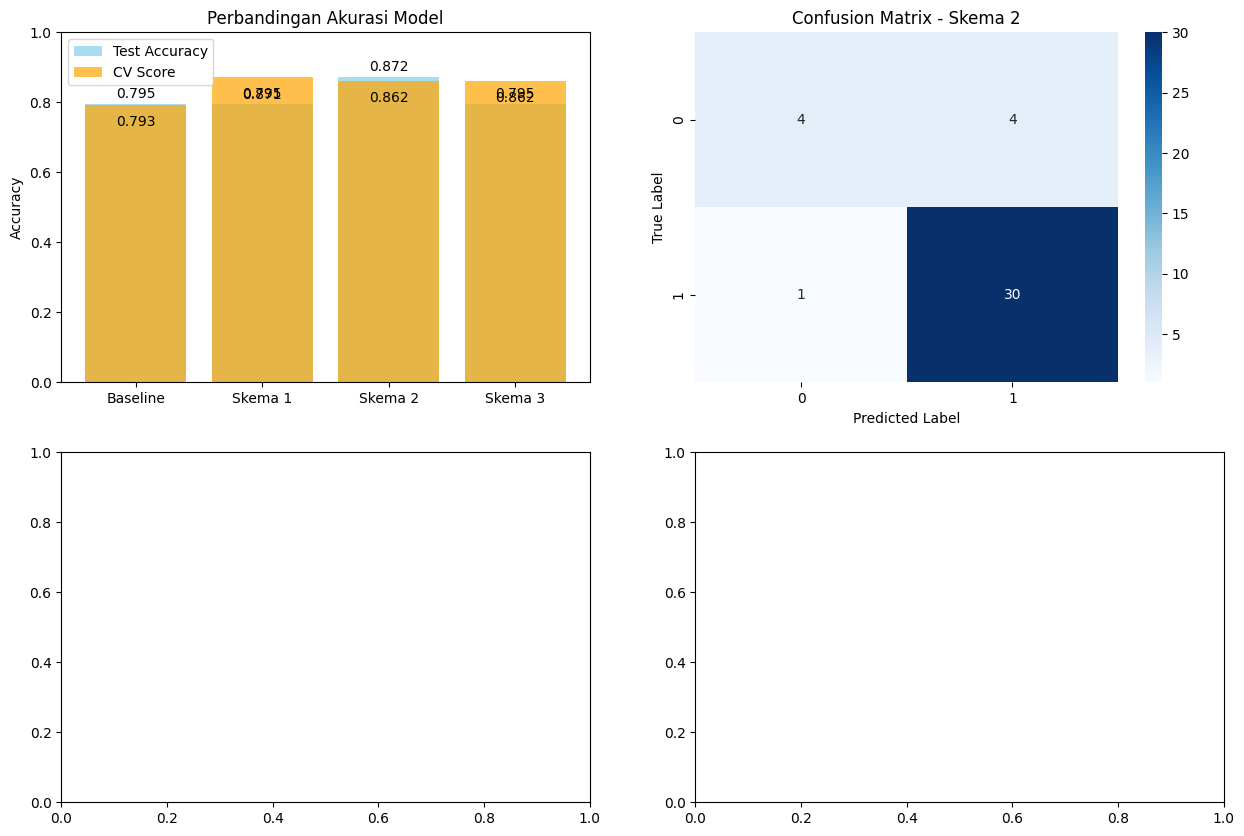

In [ ]:
# =============================================================================
# STEP 4B: VISUALISASI EVALUASI
# =============================================================================

print(f"\n📊 STEP 4B: VISUALISASI EVALUASI")
print("="*50)

# Plot perbandingan akurasi
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Bar chart perbandingan akurasi
model_names = list(models_performance.keys())
test_accuracies = [models_performance[name]['accuracy'] for name in model_names]
cv_scores = [models_performance[name]['cv_mean'] for name in model_names]

axes[0, 0].bar(model_names, test_accuracies, alpha=0.7, label='Test Accuracy', color='skyblue')
axes[0, 0].bar(model_names, cv_scores, alpha=0.7, label='CV Score', color='orange')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('Perbandingan Akurasi Model')
axes[0, 0].legend()
axes[0, 0].set_ylim(0, 1)

# Tambahkan nilai di atas bar
for i, (test_acc, cv_acc) in enumerate(zip(test_accuracies, cv_scores)):
    axes[0, 0].text(i, test_acc + 0.01, f'{test_acc:.3f}', ha='center', va='bottom')
    axes[0, 0].text(i, cv_acc - 0.03, f'{cv_acc:.3f}', ha='center', va='top')

# 2. Confusion Matrix untuk model terbaik
if best_model_name == 'Baseline':
    best_y_pred = y_pred_baseline
elif best_model_name == 'Skema 1':
    best_y_pred = y_pred_1
elif best_model_name == 'Skema 2':
    best_y_pred = y_pred_svm_2
else:
    best_y_pred = y_pred_3

cm = confusion_matrix(y_test, best_y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1])
axes[0, 1].set_title(f'Confusion Matrix - {best_model_name}')
axes[0, 1].set_ylabel('True Label')
axes[0, 1].set_xlabel('Predicted Label')

# 3. Feature importance (untuk model dengan feature selection)
if best_model_name in ['Skema 2', 'Skema 3']:
    if best_model_name == 'Skema 2':
        feature_scores = feature_selector.scores_[feature_selector.get_support()]
        title = 'Feature Importance (F-Score)'
    else:
        feature_scores = feature_selector_3.scores_[feature_selector_3.get_support()]
        title = 'Feature Importance (Mutual Info)'

    feature_names = [f'Feature_{i+1}' for i in range(len(feature_scores))]
    axes[1, 0].barh(feature_names, feature_scores)
    axes[1, 0].set_xlabel('Importance Score')
    axes[1, 0].set_title(title)
    axes[1, 0].invert_yaxis()
else:
    axes[1, 0].text(0.5, 0.5, 'Feature Selection\nTidak Digunakan',
                    ha='center', va='center', transform=axes[1, 0].transAxes)
    axes[1, 0].set_title('Feature Importance')

# 4. Akurasi per kelas
classes = np.unique(y_test)
class_accuracies = []
for cls in classes:
    mask = y_test == cls
    if mask.sum() > 0:
        acc = (best_y_pred[mask] == cls).mean()
        class_accuracies.append(acc)
    else:
        class_accuracies.append(0)

# Konversi kelas ke label asli jika ada target encoder
if target_encoder:
    class_labels = [target_encoder.inverse_transform([cls])[0] for cls in classes]
else:
    class_labels = [f'Class_{cls}' for cls in classes]

axes[1, 1].bar(class_labels, class_accuracies, color='lightgreen')
axes[1, 1].set_ylabel('Akurasi per Kelas')
axes[1, 1].set_title(f'Performa per Kelas - {best_model_name}')
axes[1, 1].set_ylim(0, 1)

# Tambahkan nilai di atas bar
for i, acc in enumerate(class_accuracies):
    axes[1, 1].text(i, acc + 0.01, f'{acc:.3f}', ha='center')

plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# STEP 4C: LAPORAN KLASIFIKASI DETAIL
# =============================================================================

print(f"\n📋 STEP 4C: LAPORAN KLASIFIKASI DETAIL - {best_model_name}")
print("="*60)

# Classification report untuk model terbaik
if target_encoder:
    target_names = target_encoder.classes_
else:
    target_names = None

report = classification_report(y_test, best_y_pred, target_names=target_names)
print(report)

# Analisis mendalam
print(f"\n🔍 ANALISIS MENDALAM:")
print(f"1️⃣ Model terbaik: {best_model_name}")
print(f"2️⃣ Test Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")

if best_model_name == 'Skema 1':
    best_params = grid_search_1.best_params_
    preprocessing = "StandardScaler"
elif best_model_name == 'Skema 2':
    best_params = grid_search_2.best_params_
    preprocessing = "RobustScaler + F-Score Feature Selection"
elif best_model_name == 'Skema 3':
    best_params = grid_search_3.best_params_
    preprocessing = "MinMaxScaler + Mutual Information Feature Selection"
else:
    best_params = "Default parameters"
    preprocessing = "No preprocessing"

print(f"3️⃣ Best Parameters: {best_params}")
print(f"4️⃣ Preprocessing: {preprocessing}")

print(f"\n🎯 RINGKASAN EKSPERIMEN:")
print(f"• Baseline Accuracy: {accuracy_baseline:.4f}")
print(f"• Best Model Accuracy: {best_accuracy:.4f}")
print(f"• Improvement: {((best_accuracy - accuracy_baseline) / accuracy_baseline * 100):.2f}%")